## 1. Imports
Load the libraries required for data preparation, modeling, and evaluation.

In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Data Loading
Read the Helsinki population and EV station datasets and prepare the analysis district list.

In [8]:
# Data loading

def load_data(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the Helsinki population and EV station datasets from disk."""
    pop_path = data_dir / "population dataset of helsinki_2018_2030.csv"
    stations_path = data_dir / "helsinki_ev_stations.csv"
    df_pop_local = pd.read_csv(pop_path, sep=";", encoding="latin-1")
    df_stations_local = pd.read_csv(stations_path, encoding="latin-1")
    return df_pop_local, df_stations_local


def build_model_frame(df_pop_local: pd.DataFrame, districts_local: list[str]) -> pd.DataFrame:
    """Filter the population data to district totals used for modeling."""
    pop_cols = ["2018", "2022", "2030"]
    df_filtered = df_pop_local.copy()

    for column in pop_cols:
        df_filtered[column] = pd.to_numeric(df_filtered[column], errors="coerce")

    mask = df_filtered["Alue/District"].isin(districts_local) & df_filtered["Ikä/Age"].str.contains("Total", na=False)
    df_model_local = df_filtered.loc[mask, ["Alue/District", *pop_cols]].dropna().copy()
    return df_model_local


data_dir = Path("..") / "dataSet"
districts = [
    "091 1 Eteläinen suurpiiri",
    "091 2 Läntinen suurpiiri",
    "091 3 Keskinen suurpiiri",
    "091 4 Pohjoinen suurpiiri",
    "091 5 Koillinen suurpiiri",
    "091 6 Kaakkoinen suurpiiri",
    "091 7 Itäinen suurpiiri",
]

df_pop, df_stations = load_data(data_dir)
df_model = build_model_frame(df_pop, districts)
df_model

,Alue/District,2018,2022,2030
37,091 1 Eteläinen suurpiiri,116443.0,123482.0,133088.0
1073,091 2 Läntinen suurpiiri,109306.0,114179.0,122040.0
2294,091 3 Keskinen suurpiiri,92618.0,100462.0,116299.0
3441,091 4 Pohjoinen suurpiiri,43112.0,44439.0,51154.0
4144,091 5 Koillinen suurpiiri,99765.0,101841.0,106731.0
5180,091 6 Kaakkoinen suurpiiri,51407.0,56990.0,68179.0
5920,091 7 Itäinen suurpiiri,112012.0,115202.0,120276.0


## 3. Feature Engineering
Create the regression and classification targets, plus growth velocity, from the population data.

In [9]:
# Feature engineering

def add_engineered_features(df_model_local: pd.DataFrame) -> pd.DataFrame:
    """Create demand, growth, and infrastructure target features."""
    df_features = df_model_local.copy()
    df_features["Growth_Rate_18_22"] = np.where(
        df_features["2018"] > 0,
        ((df_features["2022"] - df_features["2018"]) / df_features["2018"]) * 100,
        np.nan,
    )
    df_features["Power_Demand_kW"] = (df_features["2030"] / 100) * 22
    df_features["Infra_Class"] = (df_features["2030"] > 100000).astype(int)
    return df_features.dropna().copy()


df_model = add_engineered_features(df_model)
df_model

,Alue/District,2018,2022,2030,Growth_Rate_18_22,Power_Demand_kW,Infra_Class
37,091 1 Eteläinen suurpiiri,116443.0,123482.0,133088.0,6.045018,29279.36,1
1073,091 2 Läntinen suurpiiri,109306.0,114179.0,122040.0,4.458127,26848.80,1
2294,091 3 Keskinen suurpiiri,92618.0,100462.0,116299.0,8.469196,25585.78,1
3441,091 4 Pohjoinen suurpiiri,43112.0,44439.0,51154.0,3.078029,11253.88,0
4144,091 5 Koillinen suurpiiri,99765.0,101841.0,106731.0,2.080890,23480.82,1
5180,091 6 Kaakkoinen suurpiiri,51407.0,56990.0,68179.0,10.860389,14999.38,0
5920,091 7 Itäinen suurpiiri,112012.0,115202.0,120276.0,2.847909,26460.72,1


## 4. Train-Test Split
Separate the features and targets, then split the data for training and testing.

In [10]:
# Prepare features and targets
feature_cols = ["2018", "2022", "Growth_Rate_18_22"]
X = df_model[feature_cols]
y_reg = df_model["Power_Demand_kW"]
y_clf = df_model["Infra_Class"]

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

## 5. Regression Model
Train a scaled linear regression model and inspect residuals for non-linear patterns.

Regression R2 Score: 0.75


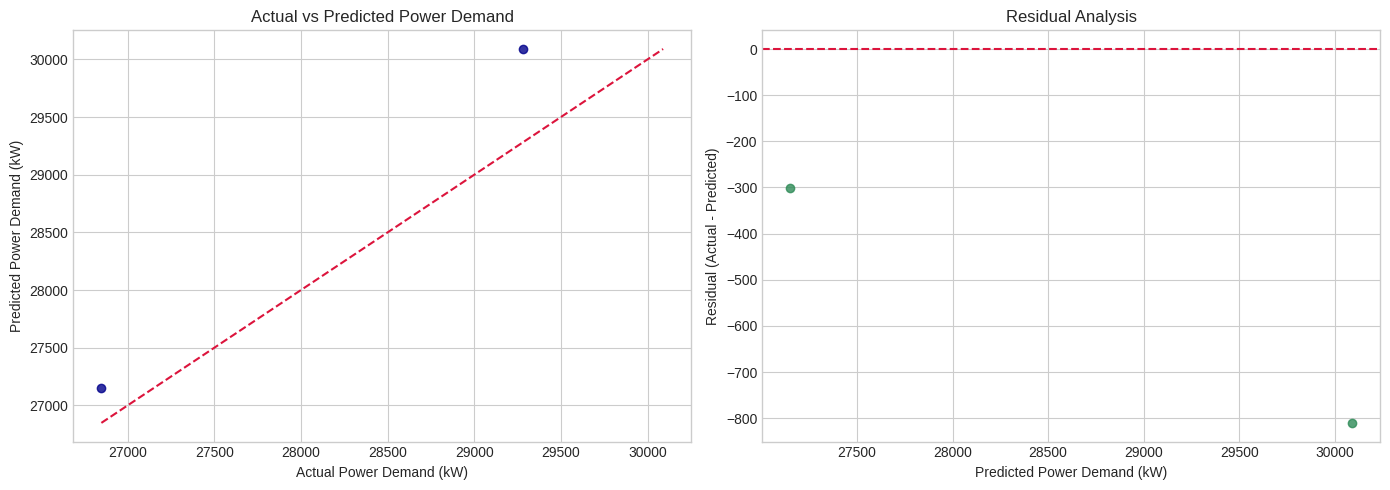

In [11]:
# Regression model

def train_scaled_regression_model(X_train: pd.DataFrame, y_train: pd.Series) -> Pipeline:
    """Train a scaled linear regression model."""
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("regressor", LinearRegression()),
        ]
    )
    model.fit(X_train, y_train)
    return model


def plot_regression_diagnostics(y_true: pd.Series, y_pred: np.ndarray) -> None:
    """Plot prediction fit and residuals to diagnose regression performance."""
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_true, y_pred, color="darkblue", alpha=0.8)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], color="crimson", linestyle="--")
    axes[0].set_title("Actual vs Predicted Power Demand")
    axes[0].set_xlabel("Actual Power Demand (kW)")
    axes[0].set_ylabel("Predicted Power Demand (kW)")

    axes[1].scatter(y_pred, residuals, color="seagreen", alpha=0.8)
    axes[1].axhline(0, color="crimson", linestyle="--")
    axes[1].set_title("Residual Analysis")
    axes[1].set_xlabel("Predicted Power Demand (kW)")
    axes[1].set_ylabel("Residual (Actual - Predicted)")

    plt.tight_layout()
    plt.show()


reg_model = train_scaled_regression_model(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)
print(f"Regression R2 Score: {reg_model.score(X_test_r, y_test_r):.2f}")
plot_regression_diagnostics(y_test_r, y_pred_r)

## 6. Classification Model
Train the decision tree classifier and evaluate it on the held-out test set.

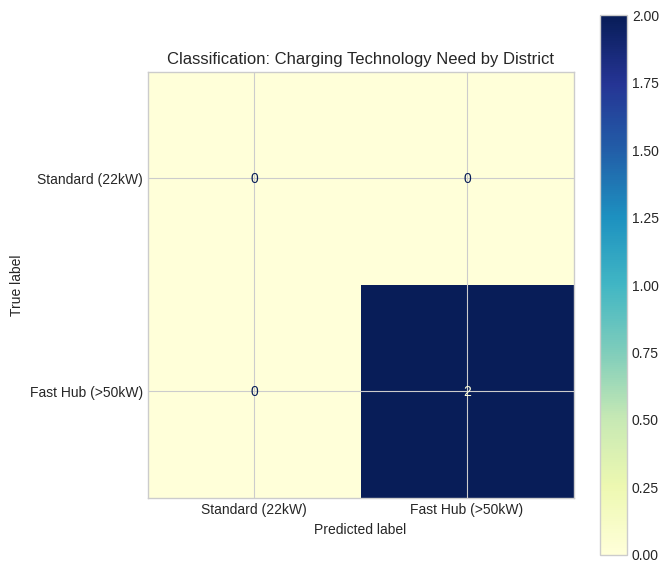


Classification Performance:
                  precision    recall  f1-score   support

 Standard (22kW)       0.00      0.00      0.00         0
Fast Hub (>50kW)       1.00      1.00      1.00         2

        accuracy                           1.00         2
       macro avg       0.50      0.50      0.50         2
    weighted avg       1.00      1.00      1.00         2



In [13]:
# Classification model

def train_classification_model(X_train: pd.DataFrame, y_train: pd.Series) -> DecisionTreeClassifier:
    """Train a decision tree classifier for charging infrastructure selection."""
    model = DecisionTreeClassifier(max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    return model


clf_model = train_classification_model(X_train_c, y_train_c)
y_pred_c = clf_model.predict(X_test_c)

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    clf_model,
    X_test_c,
    y_test_c,
    labels=[0, 1],
    display_labels=["Standard (22kW)", "Fast Hub (>50kW)"],
    cmap="YlGnBu",
    ax=ax,
)
ax.set_title("Classification: Charging Technology Need by District")
plt.tight_layout()
plt.show()

print("\nClassification Performance:")
print(classification_report(y_test_c, y_pred_c, labels=[0, 1], target_names=["Standard (22kW)", "Fast Hub (>50kW)"], zero_division=0))